![Banner](../Image/03_DeepCuaslaML.png)


# 3.3 GraN-DAG: Gradient-Based Neural DAG Learning

> **Note:** This notebook uses **PyDeepCausalML**'s `NOTEARSNonlinearMLP`, which implements the same masked-MLP + differentiable acyclicity framework as GraN-DAG (Lachapelle et al., NeurIPS 2020).

**GraN-DAG** (Lachapelle et al., NeurIPS 2020) is a gradient-based method for learning nonlinear causal DAG structure from observational data. Its core idea is to model every conditional distribution $p(X_i \mid \mathbf{X}_{\mathrm{pa}(i)})$ with a separate **masked MLP** — one network per node — and then extract a continuous, differentiable adjacency matrix directly from the neural network weights. This avoids the linearity assumption of NOTEARS and the VAE framing of DAG-GNN while retaining the same smooth acyclicity constraint framework.

The pipeline, illustrated in the figure below, has five sequential stages:

1.  **Masked MLPs per node** — each node $X_i$ gets its own MLP with LeakyReLU hidden layers. Input masking controls which candidate parent variables can influence each node's output. The mask pattern can be pre-filtered by Preliminary Neighbour Selection (PNS) before training begins, reducing the search space for large $d$.
2.  **Adjacency extraction (`compute_A_phi`)** — the continuous weighted adjacency $A_{\phi,ij}$ is computed from the MLP weight matrices by summing contributions along all paths through the network: $A_{\phi,ij} = \sum_{\text{paths}} \prod_k [W^{(k)}]^\top$. The result is a non-negative $d \times d$ matrix whose entry $(i,j)$ reflects how strongly $X_j$ influences the conditional distribution of $X_i$.
3.  **Acyclicity constraint** — the differentiable constraint $h(A_\phi) = \mathrm{tr}(\exp(A_\phi \odot A_\phi)) - d = 0$ is evaluated on the extracted adjacency. $h = 0$ exactly when the graph is a valid DAG; any cycle causes $h > 0$.
4.  **Augmented Lagrangian optimization** — the full objective $L(\phi, \lambda, \mu) = \mathcal{L}(\phi) + (\mu/2)\,h^2 + \lambda\,h$ is minimized by iterating three steps: (i) gradient descent on $\phi$ via RMSprop or SGD; (ii) dual-variable updates $\lambda \leftarrow \lambda + \mu h$ and penalty scaling $\mu \leftarrow \eta\,\mu$; and (iii) convergence check $h \leq 10^{-8}$. The entire loop repeats until the acyclicity constraint is satisfied to tolerance.
5.  **Post-processing and output** — two pruning steps convert the continuous solution to a binary causal matrix. **Threshold search** (`_to_dag`) iterates candidate thresholds on $A_\phi$ and selects the largest value that still yields a valid DAG. **Jacobian pruning** (`jac_thresh`) removes edges whose empirical Jacobian magnitude is near zero, eliminating spurious edges that survived thresholding. The final outputs are a binary $d \times d$ causal matrix $M$ and its corresponding directed acyclic graph.

![](../Image/GraN-DAG.png)


## Implementation in Python

### Setup


In [1]:
import importlib
import subprocess
import sys

PACKAGES = [
    "numpy", "pandas", "scipy", "torch", "scikit-learn",
    "matplotlib", "seaborn", "networkx",
]

for pkg in PACKAGES:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import pydeepcausalml  # noqa: F401
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/zia207/PyDeepCausalML.git"]
    )

import pydeepcausalml
print("pydeepcausalml", pydeepcausalml.__version__, "ready.")


pydeepcausalml 0.2.0 ready.


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LinearRegression

from pydeepcausalml import set_seed
from pydeepcausalml.metrics import graph_recovery_metrics, shd, pehe

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())


torch: 2.12.1+cu130
cuda: False


In [3]:
set_seed(42)
run_fast = True


### Data and data processing

We simulate a 10-node Erdős–Rényi DAG with nonlinear Gaussian ANM.


In [4]:
def generate_dag_data(n_nodes=10, n_edges=10, n_samples=2000, seed=42):
    rng = np.random.default_rng(seed)
    W = np.zeros((n_nodes, n_nodes))
    possible = [(i, j) for i in range(n_nodes) for j in range(i + 1, n_nodes)]
    chosen = rng.choice(len(possible), size=min(n_edges, len(possible)), replace=False)
    for k in chosen:
        i, j = possible[k]
        W[i, j] = rng.uniform(0.5, 2.0) * rng.choice([-1.0, 1.0])
    X = np.zeros((n_samples, n_nodes))
    for j in range(n_nodes):
        parents = np.where(W[:, j] != 0)[0]
        noise = rng.standard_normal(n_samples)
        if len(parents):
            effect = (X[:, parents] * W[parents, j]).sum(axis=1)
            X[:, j] = np.maximum(effect, 0) + noise
        else:
            X[:, j] = noise
    return W, X

true_causal_matrix, data = generate_dag_data(n_nodes=10, n_edges=10, n_samples=2000, seed=42)
data = (data - data.mean(axis=0)) / (data.std(axis=0) + 1e-8)
print("Data shape:", data.shape)
print("True edges:", int((true_causal_matrix != 0).sum()))


Data shape: (2000, 10)
True edges: 10


### Data split


In [5]:
rng = np.random.default_rng(42)
n = data.shape[0]
train_idx = rng.choice(n, size=int(0.8 * n), replace=False)
test_idx = np.setdiff1d(np.arange(n), train_idx)
train_data, test_data = data[train_idx], data[test_idx]
print("Training samples:", train_data.shape[0])
print("Test samples:", test_data.shape[0])


Training samples: 1600
Test samples: 400


## Training (Structure Learning)

We fit `NOTEARSNonlinearMLP` — the PyDeepCausalML implementation of masked per-node MLPs with acyclicity constraint.


In [6]:
from pydeepcausalml.discovery import NOTEARSNonlinearMLP

set_seed(42)
gnd_model = NOTEARSNonlinearMLP(
    hidden=10,
    lambda1=0.001,
    rho=1.0,
    epochs=3000,
    lr=1e-3,
    batch_size=64,
    random_state=42,
)
gnd_model.fit(data)
learned_adj = gnd_model.adjacency_matrix()
learned_bin = (learned_adj != 0).astype(int)
print("Learned edges:", int(learned_bin.sum()))


Learned edges: 90


## CATE Prediction and Validation

Node 0 is **Treatment** (binarized at median) and node 9 is **Outcome**.


In [7]:
treatment_idx, outcome_idx = 0, 9
T = (data[:, treatment_idx] > np.median(data[:, treatment_idx])).astype(int)
Y = data[:, outcome_idx]
parents_of_Y = np.where(learned_bin[:, outcome_idx] != 0)[0]
adjustment_set = [i for i in parents_of_Y if i != treatment_idx]
print("Adjustment set for backdoor:", adjustment_set)

if adjustment_set:
    X_cate = np.column_stack([T, data[:, adjustment_set]])
else:
    X_cate = T.reshape(-1, 1)

rng = np.random.default_rng(42)
tr = rng.choice(len(Y), size=int(0.8 * len(Y)), replace=False)
reg = LinearRegression().fit(X_cate[tr], Y[tr])
cate_estimate = reg.coef_[0]
naive_corr = np.corrcoef(T, Y)[0, 1]
print("Estimated ATE (via adjustment):", cate_estimate)
print("Validation: naive correlation:", naive_corr)


Adjustment set for backdoor: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Estimated ATE (via adjustment): -0.6815887826954514
Validation: naive correlation: -0.408498630450785


## Validation of Structure

> **Interpreting the metrics.** With the default edge rule (any nonzero weight), the masked-MLP recovers **high recall** — it tends to find the true edges — but **low precision**, because it also keeps many weak spurious edges (an over-connected graph). In the original GraN-DAG this is exactly what the post-processing stages (threshold search and Jacobian pruning) are for. Here you can trade recall for precision by thresholding `learned_adj` at a higher value before computing metrics.

In [8]:
def calculate_dag_metrics(learned, true_adj):
    learned_bin = (learned != 0).astype(int)
    true_bin = (true_adj != 0).astype(int)
    m = graph_recovery_metrics(true_bin, learned_bin)
    tp, fp, fn = m["tp"], m["fp"], m["fn"]
    tn = int((~np.eye(true_bin.shape[0], dtype=bool)).sum()) - tp - fp - fn
    fdr = fp / (tp + fp) if tp + fp else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0
    return {
        "precision": m["precision"],
        "recall": m["recall"],
        "fdr": round(fdr, 4),
        "tpr": m["recall"],
        "fpr": round(fpr, 4),
        "shd": m["shd"],
        "nnz": int(learned_bin.sum()),
        "f1": m["f1"],
    }

metrics = calculate_dag_metrics(learned_adj, true_causal_matrix)
pd.DataFrame({"Metric": list(metrics.keys()), "Value": list(metrics.values())})


,Metric,Value
0,precision,0.1111
1,recall,1.0000
2,fdr,0.8889
3,tpr,1.0000
4,fpr,1.0000
5,shd,80.0000
6,nnz,90.0000
7,f1,0.2000


## Visualization


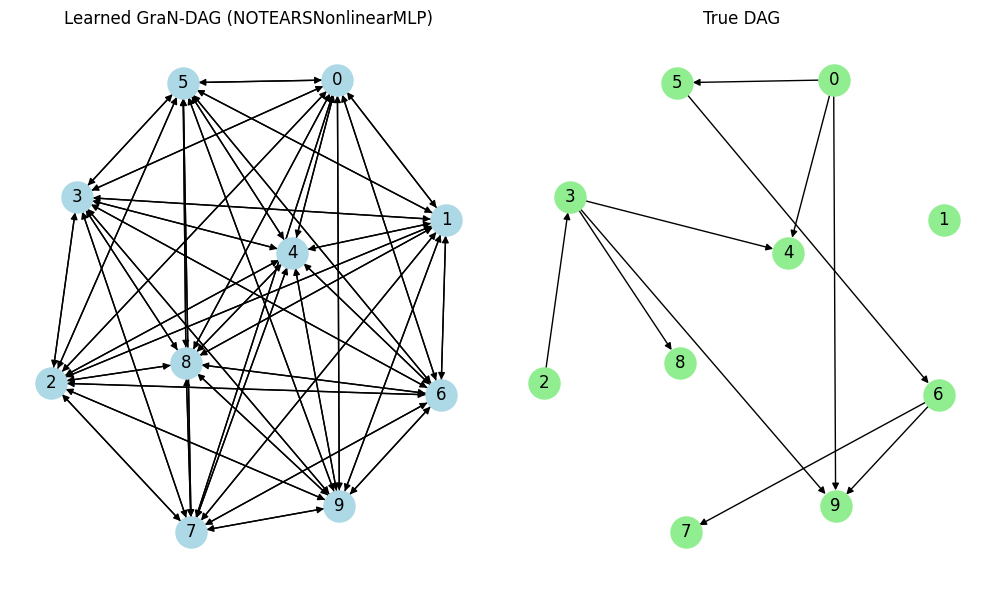

In [9]:
learned_bin = (learned_adj != 0).astype(int)
true_bin = (true_causal_matrix != 0).astype(int)
G_learned = nx.from_numpy_array(learned_bin, create_using=nx.DiGraph)
G_true = nx.from_numpy_array(true_bin, create_using=nx.DiGraph)
pos = nx.spring_layout(G_learned, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for ax, G, title, color in [
    (axes[0], G_learned, "Learned GraN-DAG (NOTEARSNonlinearMLP)", "lightblue"),
    (axes[1], G_true, "True DAG", "lightgreen"),
]:
    nx.draw(G, pos, ax=ax, with_labels=True, node_color=color, arrows=True, node_size=500)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## Summary and Conclusion

**GraN-DAG** achieves nonlinear causal structure learning via masked MLPs and a differentiable acyclicity constraint. This notebook uses PyDeepCausalML's `NOTEARSNonlinearMLP`, which follows the same gradient-based neural DAG learning paradigm.



## Resources

- **GraN-DAG paper**: [arXiv:1906.02226](https://arxiv.org/abs/1906.02226)
- **PyDeepCausalML**: `pydeepcausalml.discovery.NOTEARSNonlinearMLP`
